### Probability of Success Reversal  

Running reversal analysis from CSV files...


===== SMCI results =====
Signal Date  Window N  Max Drop %  Recover %  Success?
 2026-03-03         1        6.75     152.56      True
 2026-03-03         2        6.75     178.14      True
 2026-03-03         3        6.75     178.14      True
Signal days: 175   Success rate: 76.0%

===== SOXL results =====
Signal Date  Window N  Max Drop %  Recover %  Success?
 2026-03-05         1         9.7      40.62     False
Signal days: 192   Success rate: 77.6%

===== TQQQ results =====
Signal Date  Window N  Max Drop %  Recover %  Success?
 2026-03-05         1        4.16      42.11     False
Signal days: 88   Success rate: 75.0%

===== COIN results =====
Signal Date  Window N  Max Drop %  Recover %  Success?
 2026-03-03         1        7.12     303.41      True
 2026-03-03         2        7.12     314.25      True
 2026-03-03         3        7.12     314.25      True
Signal days: 185   Success rate: 74.6%

===== MSTR results =====
Signal Dat

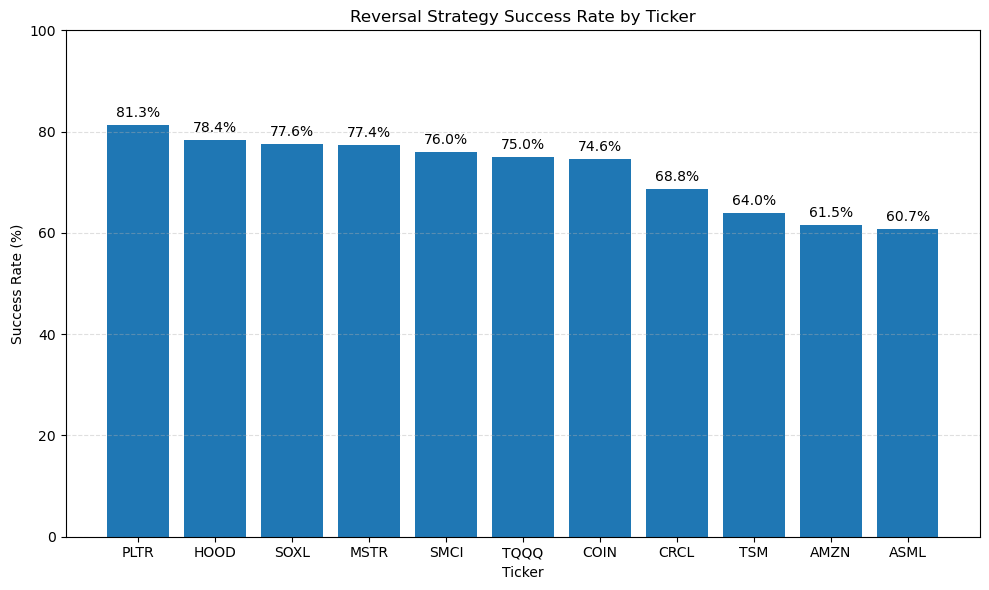

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------- USER CONFIG ----------------
BASE_DIR         = Path.cwd()
DATA_DIR         = BASE_DIR / "reversal_data"

TICKERS          = ["SMCI", "SOXL", "TQQQ", "COIN", "MSTR", "HOOD", "PLTR", "ASML", "CRCL", "TSM", "AMZN"]
DROP_THR         = 0.04            # >= 4% intraday drop triggers a signal
RECOVER_TARGET   = 0.7             # >= 70% recovery judged "success"
LOOKAHEAD        = [1, 2, 3, 4]    # T+N trading-day windows

SAVE_PLOT        = True
PLOT_PATH        = BASE_DIR / "success_rate_comparison.png"
# ------------------------------------------


def load_ticker_csv(ticker: str, data_dir: Path) -> pd.DataFrame:
    file_path = data_dir / f"{ticker}.csv"
    if not file_path.exists():
        raise FileNotFoundError(f"{ticker}: file not found -> {file_path}")

    df = pd.read_csv(file_path)

    # 清洗列名
    df.columns = (
        df.columns
        .str.replace(r'[\xa0\u3000\t]', ' ', regex=True)
        .str.strip()
    )

    # 转换类型
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    for col in ["Open", "High", "Low", "Adj Close", "Max Drop"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 保持你原策略逻辑：分析前先升序，再算 Prev Close
    df = df.sort_values("Date").reset_index(drop=True)
    df["Prev Close"] = df["Adj Close"].shift(1).fillna(df["Adj Close"])

    return df


def analyze(df: pd.DataFrame, name: str):
    signals = df[df["Max Drop"] >= DROP_THR].copy()
    rows = []

    for idx, row in signals.iterrows():
        prev_close = row["Prev Close"]
        low_today = row["Low"]

        # 你的原策略逻辑，不改
        fall_amt = row["Max Drop"] * prev_close
        # fall_amt = prev_close - low_today   # alternate formula
        if fall_amt <= 0 or np.isnan(fall_amt):
            continue

        for N in LOOKAHEAD:
            if idx + N >= len(df):
                break

            high_n = df.loc[idx + 1: idx + N, "High"].max()
            recover_ratio = (high_n - low_today) / fall_amt

            rows.append({
                "Signal Date": row["Date"].date(),
                "Window N": N,
                "Max Drop %": round(row["Max Drop"] * 100, 2),
                "Recover %": round(recover_ratio * 100, 2),
                "Success?": recover_ratio >= RECOVER_TARGET,
            })

    result = pd.DataFrame(rows)

    success_rate = (
        result.groupby("Signal Date")["Success?"].any().mean() * 100
        if not result.empty else 0
    )

    print(f"\n===== {name} results =====")

    if result.empty:
        print("No qualifying signals found.")
        print("Signal days: 0   Success rate: 0.0%")
        return {
            "ticker": name,
            "signal_days": 0,
            "success_rate": 0.0,
            "result": result
        }

    # 只显示最近一个 signal day
    latest_date = result["Signal Date"].max()
    recent_rows = result[result["Signal Date"] == latest_date]
    recent_rows = recent_rows.sort_values("Window N")

    print(recent_rows.to_string(index=False))
    print(f"Signal days: {result['Signal Date'].nunique()}   "
          f"Success rate: {success_rate:.1f}%")

    return {
        "ticker": name,
        "signal_days": int(result["Signal Date"].nunique()),
        "success_rate": float(success_rate),
        "result": result
    }


def plot_success_rates(summary_df: pd.DataFrame, save_plot: bool = True, plot_path: Path | None = None):
    if summary_df.empty:
        print("\nNo summary data to plot.")
        return

    plot_df = summary_df.sort_values("success_rate", ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 6))
    bars = plt.bar(plot_df["ticker"], plot_df["success_rate"])

    plt.title("Reversal Strategy Success Rate by Ticker")
    plt.xlabel("Ticker")
    plt.ylabel("Success Rate (%)")
    plt.ylim(0, 100)
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    # 在柱子上方标注数值
    for bar, rate in zip(bars, plot_df["success_rate"]):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{rate:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.tight_layout()

    if save_plot and plot_path is not None:
        plt.savefig(plot_path, dpi=150, bbox_inches="tight")
        print(f"\nSaved plot -> {plot_path}")

    plt.show()


def main():
    print("Running reversal analysis from CSV files...\n")

    summary_rows = []

    for ticker in TICKERS:
        try:
            df = load_ticker_csv(ticker, DATA_DIR)
            out = analyze(df, ticker)

            summary_rows.append({
                "ticker": out["ticker"],
                "signal_days": out["signal_days"],
                "success_rate": out["success_rate"]
            })

        except Exception as e:
            print(f"{ticker}: failed -> {e}")

    summary_df = pd.DataFrame(summary_rows)

    if not summary_df.empty:
        print("\n===== Summary =====")
        print(summary_df.sort_values("success_rate", ascending=False).to_string(index=False))

    plot_success_rates(summary_df, save_plot=SAVE_PLOT, plot_path=PLOT_PATH)


if __name__ == "__main__":
    main()

### Black Scholes Methods for Profitability Confidence Interval 

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.stats import norm
from datetime import datetime

# ========= USER INPUT =========
TICKERS_TO_RUN = ["TQQQ"]

STRIKE = 45
CALL_COST = 6.16

IMPLIED_VOL = 0.9036
USE_ROLLING_SIGMA = False
ROLL_WIN = 20

EXPIRY_DATE = "2026-04-02"

CONF_LEVEL = 0.9
RISK_FREE = 0.035
BOOT_SIMS = 30000
# ===============================

# reuse config from previous analysis cell
DROP_THR = 0.04
LOOKAHEAD = [1,2,3,4]

DATA_DIR = Path.cwd() / "reversal_data"

# compute days to expiry
today = datetime.today()
expiry = datetime.strptime(EXPIRY_DATE,"%Y-%m-%d")
DAYS_TO_EXP = max((expiry - today).days,0)

# ---------- Black-Scholes ----------
def bs_call(spot,strike,t,r,sigma):

    if t<=0:
        return np.maximum(spot-strike,0)

    d1=(np.log(spot/strike)+(r+0.5*sigma**2)*t)/(sigma*np.sqrt(t))
    d2=d1-sigma*np.sqrt(t)

    return spot*norm.cdf(d1)-strike*np.exp(-r*t)*norm.cdf(d2)


# ---------- CI engine ----------
def option_return_ci(df,lookahead,spot,strike,cost,iv,
                     tau_days,drop_thr,conf,r,n_boot):

    signals=df[df["Max Drop"]>=drop_thr]

    logret={n:[] for n in lookahead}

    for idx,row in signals.iterrows():

        s0=row["Adj Close"]

        for n in lookahead:

            if idx+n>=len(df):
                break

            sn=df.loc[idx+n,"Adj Close"]

            logret[n].append(np.log(sn/s0))


    a_lo=(1-conf)/2
    a_hi=1-(1-conf)/2

    rows=[]

    for n in lookahead:

        sample=np.asarray(logret[n])

        if sample.size==0:
            continue

        draws=np.random.choice(sample,size=n_boot,replace=True)

        tau=max((tau_days-n)/365,0)

        spots=spot*np.exp(draws)

        calls=bs_call(spots,strike,tau,r,iv)

        rets=(calls-cost)/cost

        rows.append({
            "N":n,
            "mean_%":round(rets.mean()*100,2),
            f"{int(conf*100)}%_low_%":round(np.quantile(rets,a_lo)*100,2),
            f"{int(conf*100)}%_high_%":round(np.quantile(rets,a_hi)*100,2),
            "samples":sample.size
        })

    return pd.DataFrame(rows)


# ---------- run ----------
for ticker in TICKERS_TO_RUN:

    try:

        df=pd.read_csv(DATA_DIR/f"{ticker}.csv")

        df["Date"]=pd.to_datetime(df["Date"])

        df=df.sort_values("Date").reset_index(drop=True)

        # get current price
        hist=yf.download(ticker,period="5d",progress=False)

        if isinstance(hist.columns,pd.MultiIndex):
            hist.columns=hist.columns.get_level_values(0)

        spot=float(hist["Close"].iloc[-1])

        # optional rolling sigma
        iv_use=IMPLIED_VOL

        if USE_ROLLING_SIGMA:

            log_r=np.log(df["Adj Close"]/df["Adj Close"].shift(1)).dropna()

            sigma_d=log_r.rolling(ROLL_WIN).std().iloc[-1]

            if not np.isnan(sigma_d):
                iv_use=sigma_d*np.sqrt(252)

        ci=option_return_ci(df,
                            LOOKAHEAD,
                            spot,
                            STRIKE,
                            CALL_COST,
                            iv_use,
                            DAYS_TO_EXP,
                            DROP_THR,
                            CONF_LEVEL,
                            RISK_FREE,
                            BOOT_SIMS)

        print(f"\n===== {ticker} Call Option Profitability =====")

        print(f"Spot: {spot:.2f}")
        print(f"Strike: {STRIKE}")
        print(f"Cost: {CALL_COST}")
        print(f"IV used: {iv_use:.2f}")
        print(f"DTE: {DAYS_TO_EXP}")

        print(ci.to_string(index=False))

    except Exception as e:

        print(f"{ticker} failed -> {e}")


===== TQQQ Call Option Profitability =====
Spot: 47.54
Strike: 45
Cost: 6.16
IV used: 0.90
DTE: 23
 N  mean_%  90%_low_%  90%_high_%  samples
 1   -3.03     -36.26       27.37       88
 2   -3.72     -51.76       39.03       87
 3   -3.43     -54.32       55.01       87
 4   -3.51     -68.91       83.44       86


### Geometric Brownian Motion Methods for Profitability Confidence Interval 

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.stats import norm
from datetime import datetime
from pathlib import Path

# ========= USER INPUTS =========
TICKERS_TO_RUN = ["TQQQ"]

STRIKE = 45
CALL_COST = 6.16

EXPIRY_DATE = "2026-04-02"
LOOKAHEAD = [1, 2, 3, 4]
CONF_LEVEL = 0.90

DRIFT_MODE = "rf"          # "hist" or "rf"
PATHS = 50000
RISK_FREE = 0.035

# 波动率设置：
# None       -> 用全样本历史波动率
# "rolling"  -> 用 rolling window 年化波动率
# 0.60       -> 直接指定 60% annual vol
SIGMA_OVERRIDE = "rolling"
ROLL_WIN = 20

DATA_DIR = Path.cwd() / "reversal_data"
# ===============================


# ---------- helpers ----------
def bs_call(spot, strike, t, r, sigma):
    spot = np.asarray(spot, dtype=float)

    if t <= 0:
        return np.maximum(spot - strike, 0.0)

    if sigma <= 0 or np.isnan(sigma):
        return np.maximum(spot - strike * np.exp(-r * t), 0.0)

    d1 = (np.log(spot / strike) + (r + 0.5 * sigma**2) * t) / (sigma * np.sqrt(t))
    d2 = d1 - sigma * np.sqrt(t)
    return spot * norm.cdf(d1) - strike * np.exp(-r * t) * norm.cdf(d2)


def get_current_spot(ticker: str) -> float:
    hist = yf.download(
        ticker,
        period="5d",
        auto_adjust=False,
        progress=False,
        threads=False
    )

    if hist.empty:
        raise ValueError(f"{ticker}: unable to fetch recent market price.")

    if isinstance(hist.columns, pd.MultiIndex):
        hist.columns = hist.columns.get_level_values(0)

    if "Close" not in hist.columns:
        raise ValueError(f"{ticker}: 'Close' column not found.")

    close = pd.to_numeric(hist["Close"], errors="coerce").dropna()
    if close.empty:
        raise ValueError(f"{ticker}: recent Close data is empty.")

    return float(close.iloc[-1])


def compute_days_to_expiry(expiry_date_str: str) -> int:
    today = datetime.today()
    expiry = datetime.strptime(expiry_date_str, "%Y-%m-%d")
    return max((expiry - today).days, 0)


def load_ticker_csv(ticker: str, data_dir: Path) -> pd.DataFrame:
    file_path = data_dir / f"{ticker}.csv"
    if not file_path.exists():
        raise FileNotFoundError(f"{ticker}: file not found -> {file_path}")

    df = pd.read_csv(file_path)

    df.columns = (
        df.columns
        .str.replace(r'[\xa0\u3000\t]', ' ', regex=True)
        .str.strip()
    )

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    for col in ["Open", "High", "Low", "Adj Close", "Max Drop"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.sort_values("Date").reset_index(drop=True)
    return df


def get_sigma_inputs(df: pd.DataFrame, sigma_override=None, roll_win=20):
    """
    返回:
    sigma_d : daily vol
    sigma_a : annualized vol
    sigma_label : 说明字符串
    """
    log_r = np.log(df["Adj Close"] / df["Adj Close"].shift(1)).dropna()

    if log_r.empty:
        raise ValueError("Not enough price history to estimate volatility.")

    if sigma_override is None:
        sigma_d = float(log_r.std(ddof=1))
        sigma_a = float(sigma_d * np.sqrt(252))
        sigma_label = "historical full-sample sigma"

    elif isinstance(sigma_override, str) and sigma_override.lower() == "rolling":
        sigma_d = float(log_r.rolling(roll_win).std().iloc[-1])
        if np.isnan(sigma_d):
            raise ValueError(f"Rolling sigma unavailable for window={roll_win}.")
        sigma_a = float(sigma_d * np.sqrt(252))
        sigma_label = f"rolling {roll_win}-day sigma"

    else:
        # 认为传入的是 annualized vol，比如 0.60
        sigma_a = float(sigma_override)
        sigma_d = float(sigma_a / np.sqrt(252))
        sigma_label = f"user override sigma={sigma_a:.2%}"

    return sigma_d, sigma_a, sigma_label


def gbm_ci(df, spot_now, strike, cost, lookahead,
           days_to_exp, conf=0.95, paths=50000,
           drift_mode="hist", r=0.05, sigma_override=None, roll_win=20):

    # --- daily μ, σ ---
    log_r = np.log(df["Adj Close"] / df["Adj Close"].shift(1)).dropna()
    if log_r.empty:
        return pd.DataFrame()

    sigma_d, sigma_a, sigma_label = get_sigma_inputs(
        df, sigma_override=sigma_override, roll_win=roll_win
    )

    mu_d = float(log_r.mean()) if drift_mode == "hist" else float(r / 252)

    rows = []
    lo = (1 - conf) / 2
    hi = 1 - lo

    for n in lookahead:
        z = np.random.normal(size=paths)
        lnS = (mu_d - 0.5 * sigma_d**2) * n + sigma_d * np.sqrt(n) * z
        spots = spot_now * np.exp(lnS)

        tau = max((days_to_exp - n) / 365, 0)
        calls = bs_call(spots, strike, tau, r, sigma_a)
        ret = (calls - cost) / cost

        rows.append({
            "N": n,
            "mean_%": round(ret.mean() * 100, 2),
            f"{int(conf*100)}%_low_%": round(np.quantile(ret, lo) * 100, 2),
            f"{int(conf*100)}%_high_%": round(np.quantile(ret, hi) * 100, 2),
            "sigma_ann_%": round(sigma_a * 100, 2)
        })

    out = pd.DataFrame(rows)
    return out, sigma_a, sigma_label


# ---------- run ----------
DAYS_TO_EXP = compute_days_to_expiry(EXPIRY_DATE)

for ticker in TICKERS_TO_RUN:
    try:
        df = load_ticker_csv(ticker, DATA_DIR)
        spot_now = get_current_spot(ticker)

        ci_gbm, sigma_ann, sigma_label = gbm_ci(
            df=df,
            spot_now=spot_now,
            strike=STRIKE,
            cost=CALL_COST,
            lookahead=LOOKAHEAD,
            days_to_exp=DAYS_TO_EXP,
            conf=CONF_LEVEL,
            paths=PATHS,
            drift_mode=DRIFT_MODE,
            r=RISK_FREE,
            sigma_override=SIGMA_OVERRIDE,
            roll_win=ROLL_WIN
        )

        print(f"\n===== {ticker} GBM {STRIKE}-strike Call ({int(CONF_LEVEL*100)}% CI) =====")
        print(f"Spot: {spot_now:.2f}")
        print(f"Strike: {STRIKE}")
        print(f"Call Cost: {CALL_COST}")
        print(f"DTE: {DAYS_TO_EXP}")
        print(f"Drift Mode: {DRIFT_MODE}")
        print(f"Sigma Used: {sigma_label} ({sigma_ann:.2%})")

        if ci_gbm.empty:
            print("No output.")
        else:
            print(ci_gbm.to_string(index=False))

    except Exception as e:
        print(f"{ticker} failed -> {e}")


===== TQQQ GBM 45-strike Call (90% CI) =====
Spot: 47.54
Strike: 45
Call Cost: 6.16
DTE: 23
Drift Mode: rf
Sigma Used: rolling 20-day sigma (51.84%)
 N  mean_%  90%_low_%  90%_high_%  sigma_ann_%
 1  -35.63     -61.69       -4.79        51.84
 2  -34.98     -70.88       10.37        51.84
 3  -34.76     -76.99       22.54        51.84
 4  -34.44     -81.84       32.65        51.84


### Rolling Sigma

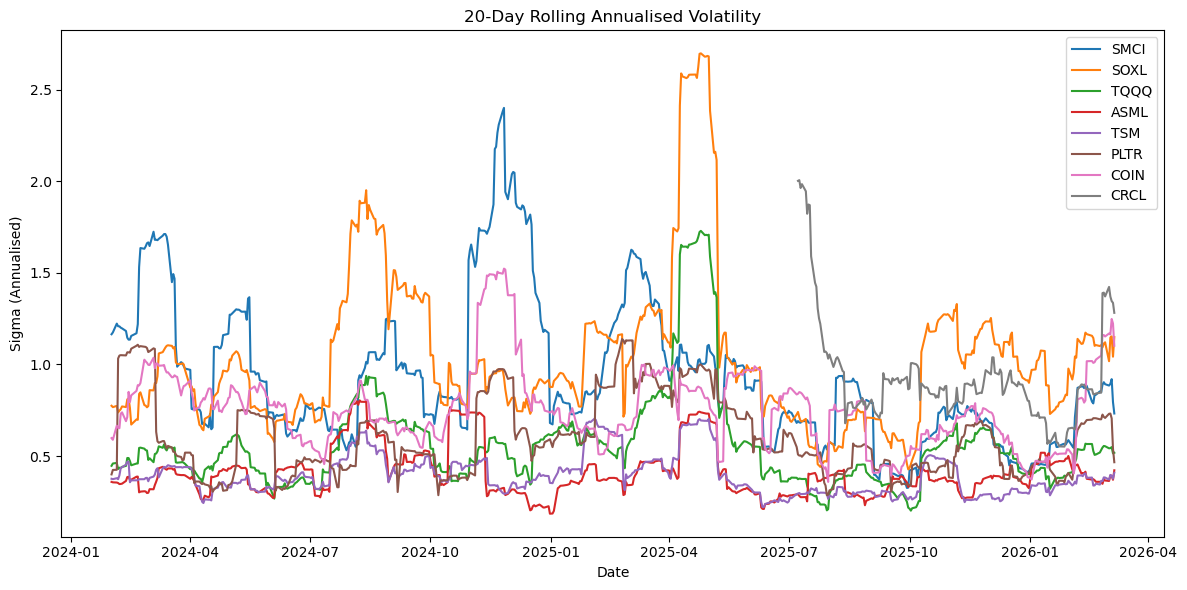

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

rolling_window = 20
DATA_DIR = Path.cwd() / "reversal_data"


def plot_rolling_sigma(ticker_list, win=rolling_window, ann_factor=252):

    """
    Plot rolling annualised sigma using CSV data from reversal_data.
    """

    plt.figure(figsize=(12,6))
    failed=[]

    for tic in ticker_list:

        try:

            file_path = DATA_DIR / f"{tic}.csv"

            if not file_path.exists():
                raise FileNotFoundError(f"{file_path} not found")

            df = pd.read_csv(file_path)

            df.columns = (
                df.columns
                .str.replace(r'[\xa0\u3000\t]', ' ', regex=True)
                .str.strip()
            )

            df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
            df["Adj Close"] = pd.to_numeric(df["Adj Close"], errors="coerce")

            df = df.sort_values("Date").reset_index(drop=True)

            # log returns
            log_r = np.log(df["Adj Close"] / df["Adj Close"].shift(1))

            # rolling sigma
            roll_sig = log_r.rolling(win).std() * np.sqrt(ann_factor)

            plt.plot(df["Date"], roll_sig, label=tic)

        except Exception as e:

            failed.append(tic)
            print(f"{tic} failed -> {e}")

    if failed:
        print("Could not plot:", ", ".join(failed))

    plt.title(f"{win}-Day Rolling Annualised Volatility")
    plt.xlabel("Date")
    plt.ylabel("Sigma (Annualised)")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_rolling_sigma(["SMCI","SOXL","TQQQ", "ASML", "TSM", "PLTR", "COIN", "CRCL"])